# 08 — Comparaison données Live (Capital.com) vs CSV (backtesting.com)

Vérifie si les deux sources décrivent les mêmes niveaux de prix sur la période commune.

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
while not (ROOT / 'pyproject.toml').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
print(f'ROOT = {ROOT}')

ROOT = c:\Users\ali\Desktop\Projet-INFO-2AS2


In [2]:
# ── Chargement Live (Capital.com) ─────────────────────────────────────────────
live_raw = pd.read_csv(ROOT / 'data' / 'dax_live_5min.csv', index_col=0, parse_dates=True)
live_raw.index = pd.to_datetime(live_raw.index, utc=True).tz_convert('Europe/Berlin').tz_localize(None)
live = live_raw[~live_raw.index.duplicated()].sort_index().between_time('09:00', '17:35')

# ── Chargement CSV (backtesting.com) ──────────────────────────────────────────
csv_raw = pd.read_csv(
    ROOT / 'data' / 'dax-5m_bk.csv', sep=';', header=None,
    names=['date', 'time', 'open', 'high', 'low', 'close', 'volume'],
)
csv_raw['datetime'] = pd.to_datetime(csv_raw['date'] + ' ' + csv_raw['time'], format='%d/%m/%Y %H:%M')
csv_raw = csv_raw.drop(columns=['date', 'time']).set_index('datetime').sort_index()

# ── Période commune ───────────────────────────────────────────────────────────
START = live.index[0].date()
END   = min(live.index[-1].date(), csv_raw.index[-1].date())

live_c = live.loc[str(START):str(END)]
csv_c  = csv_raw.loc[str(START):str(END)].between_time('09:00', '17:35')

print(f'Période commune : {START} → {END}')
print(f'Live  : {len(live_c):,} bougies')
print(f'CSV   : {len(csv_c):,} bougies')

Période commune : 2025-04-07 → 2026-04-06
Live  : 21,902 bougies
CSV   : 18,548 bougies


In [3]:
# ── Alignement sur timestamps communs ─────────────────────────────────────────
common_idx = live_c.index.intersection(csv_c.index)
live_a = live_c.loc[common_idx]
csv_a  = csv_c.loc[common_idx]

print(f'Timestamps communs : {len(common_idx):,}')
print(f'Live uniquement    : {len(live_c) - len(common_idx):,}')
print(f'CSV uniquement     : {len(csv_c)  - len(common_idx):,}')

Timestamps communs : 13,782
Live uniquement    : 8,120
CSV uniquement     : 4,766


In [4]:
# ── Différences de prix sur les timestamps communs ────────────────────────────
for col in ['open', 'high', 'low', 'close']:
    diff = (live_a[col] - csv_a[col]).dropna()
    print(f'{col.upper()}')
    print(f'  Moyenne diff : {diff.mean():+.3f} pts')
    print(f'  Std diff     : {diff.std():.3f} pts')
    print(f'  Max diff abs : {diff.abs().max():.3f} pts')
    print(f'  % diff > 1pt : {(diff.abs() > 1).mean()*100:.1f}%')
    print()

OPEN
  Moyenne diff : -83.979 pts
  Std diff     : 187.928 pts
  Max diff abs : 2177.183 pts
  % diff > 1pt : 99.6%

HIGH
  Moyenne diff : -80.748 pts
  Std diff     : 188.372 pts
  Max diff abs : 2202.673 pts
  % diff > 1pt : 99.6%

LOW
  Moyenne diff : -87.607 pts
  Std diff     : 187.835 pts
  Max diff abs : 2139.196 pts
  % diff > 1pt : 99.6%

CLOSE
  Moyenne diff : -84.324 pts
  Std diff     : 188.190 pts
  Max diff abs : 2182.182 pts
  % diff > 1pt : 99.7%



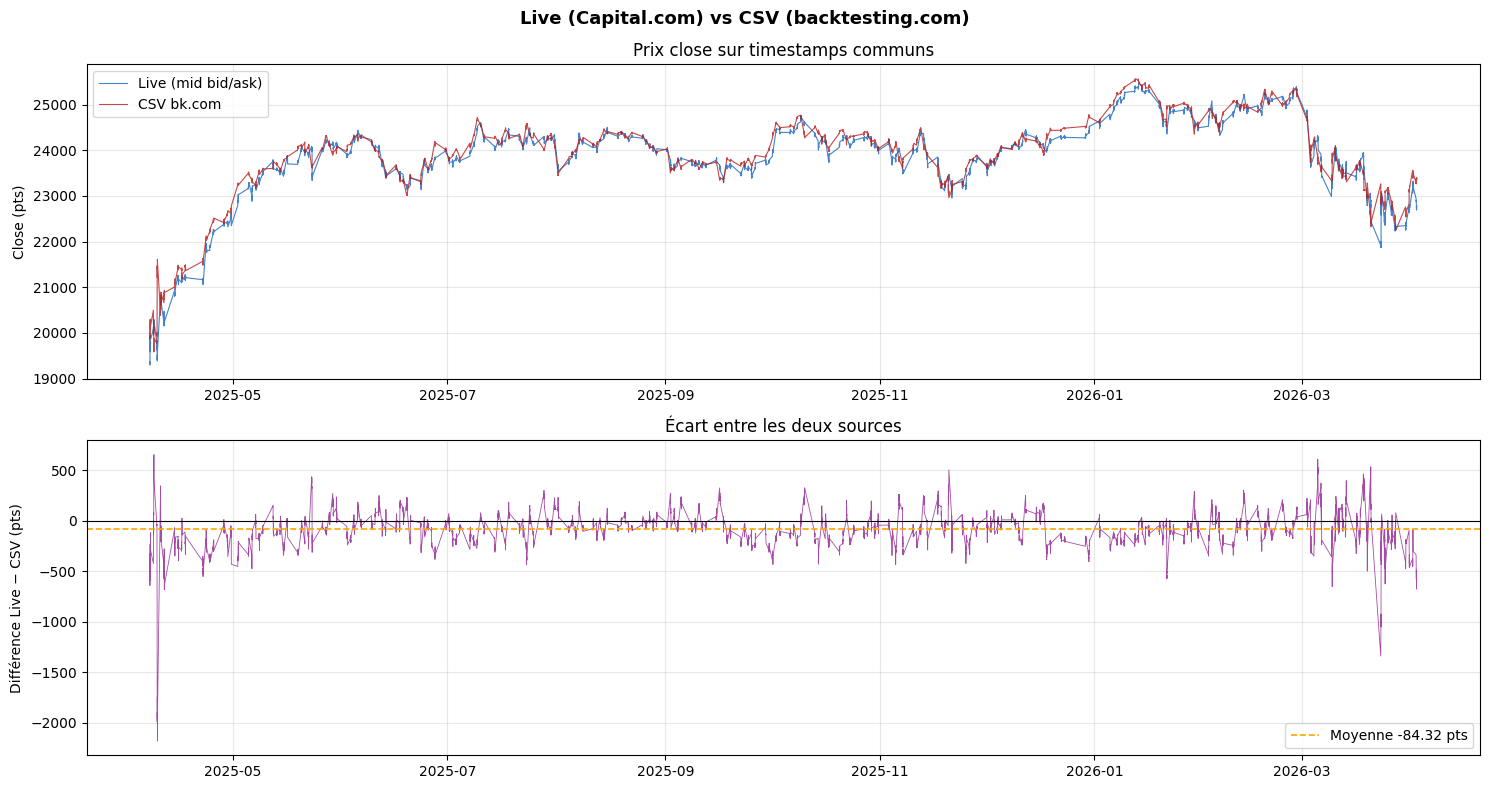

In [5]:
# ── Visualisation : close Live vs CSV sur la période commune ──────────────────
fig, axes = plt.subplots(2, 1, figsize=(15, 8))
fig.suptitle('Live (Capital.com) vs CSV (backtesting.com)', fontsize=13, fontweight='bold')

# Prix close
axes[0].plot(live_a.index, live_a['close'], color='#1565C0', lw=0.8, label='Live (mid bid/ask)', alpha=0.8)
axes[0].plot(csv_a.index,  csv_a['close'],  color='#B71C1C', lw=0.8, label='CSV bk.com',        alpha=0.8)
axes[0].set_ylabel('Close (pts)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_title('Prix close sur timestamps communs')

# Différence close
diff_close = (live_a['close'] - csv_a['close']).dropna()
axes[1].plot(diff_close.index, diff_close.values, color='purple', lw=0.6, alpha=0.7)
axes[1].axhline(0, color='black', lw=0.8)
axes[1].axhline(diff_close.mean(), color='orange', lw=1.2, ls='--', label=f'Moyenne {diff_close.mean():+.2f} pts')
axes[1].set_ylabel('Différence Live − CSV (pts)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_title('Écart entre les deux sources')

plt.tight_layout()
plt.savefig(ROOT / 'data' / 'compare_live_csv.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
# ── Corrélation ───────────────────────────────────────────────────────────────
for col in ['open', 'high', 'low', 'close']:
    corr = live_a[col].corr(csv_a[col])
    print(f'Corrélation {col.upper()} : {corr:.6f}')

Corrélation OPEN : 0.979240
Corrélation HIGH : 0.978981
Corrélation LOW : 0.979415
Corrélation CLOSE : 0.979181


In [7]:
# ── Comparaison journalière : PDH/PDL de chaque source ────────────────────────
dates = sorted(set(live_c.index.date) & set(csv_c.index.date))

rows = []
for d in dates:
    l = live_c.loc[str(d)]
    c = csv_c.loc[str(d)]
    if len(l) < 2 or len(c) < 2:
        continue
    rows.append({
        'date':      d,
        'live_high': l['high'].max(),
        'csv_high':  c['high'].max(),
        'live_low':  l['low'].min(),
        'csv_low':   c['low'].min(),
        'diff_high': l['high'].max() - c['high'].max(),
        'diff_low':  l['low'].min()  - c['low'].min(),
    })

df_days = pd.DataFrame(rows).set_index('date')

print('=== Différences journalières PDH/PDL ===')
print(f"High : moy={df_days['diff_high'].mean():+.2f} | std={df_days['diff_high'].std():.2f} | max={df_days['diff_high'].abs().max():.2f}")
print(f"Low  : moy={df_days['diff_low'].mean():+.2f}  | std={df_days['diff_low'].std():.2f} | max={df_days['diff_low'].abs().max():.2f}")
print()
print('Top 5 jours avec le plus grand écart sur le High :')
print(df_days.nlargest(5, 'diff_high')[['live_high', 'csv_high', 'diff_high', 'diff_low']].to_string())

=== Différences journalières PDH/PDL ===
High : moy=-59.24 | std=161.62 | max=1806.41
Low  : moy=-104.18  | std=124.93 | max=919.95

Top 5 jours avec le plus grand écart sur le High :
            live_high      csv_high   diff_high    diff_low
date                                                       
2025-05-23   24104.25  23711.888503  392.361497 -331.067620
2026-03-18   23960.95  23634.739052  326.210948  345.900225
2026-03-06   23995.85  23694.692730  301.157270 -104.138055
2026-03-05   24369.05  24108.373107  260.676893   77.341829
2025-07-28   24317.75  24085.222320  232.527680  -45.958513
